/var/folders/c7/kt215xrj6118ksq6w0c3ffqm0000gn/T/ipykernel_5075/2339333288.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab20', 15)


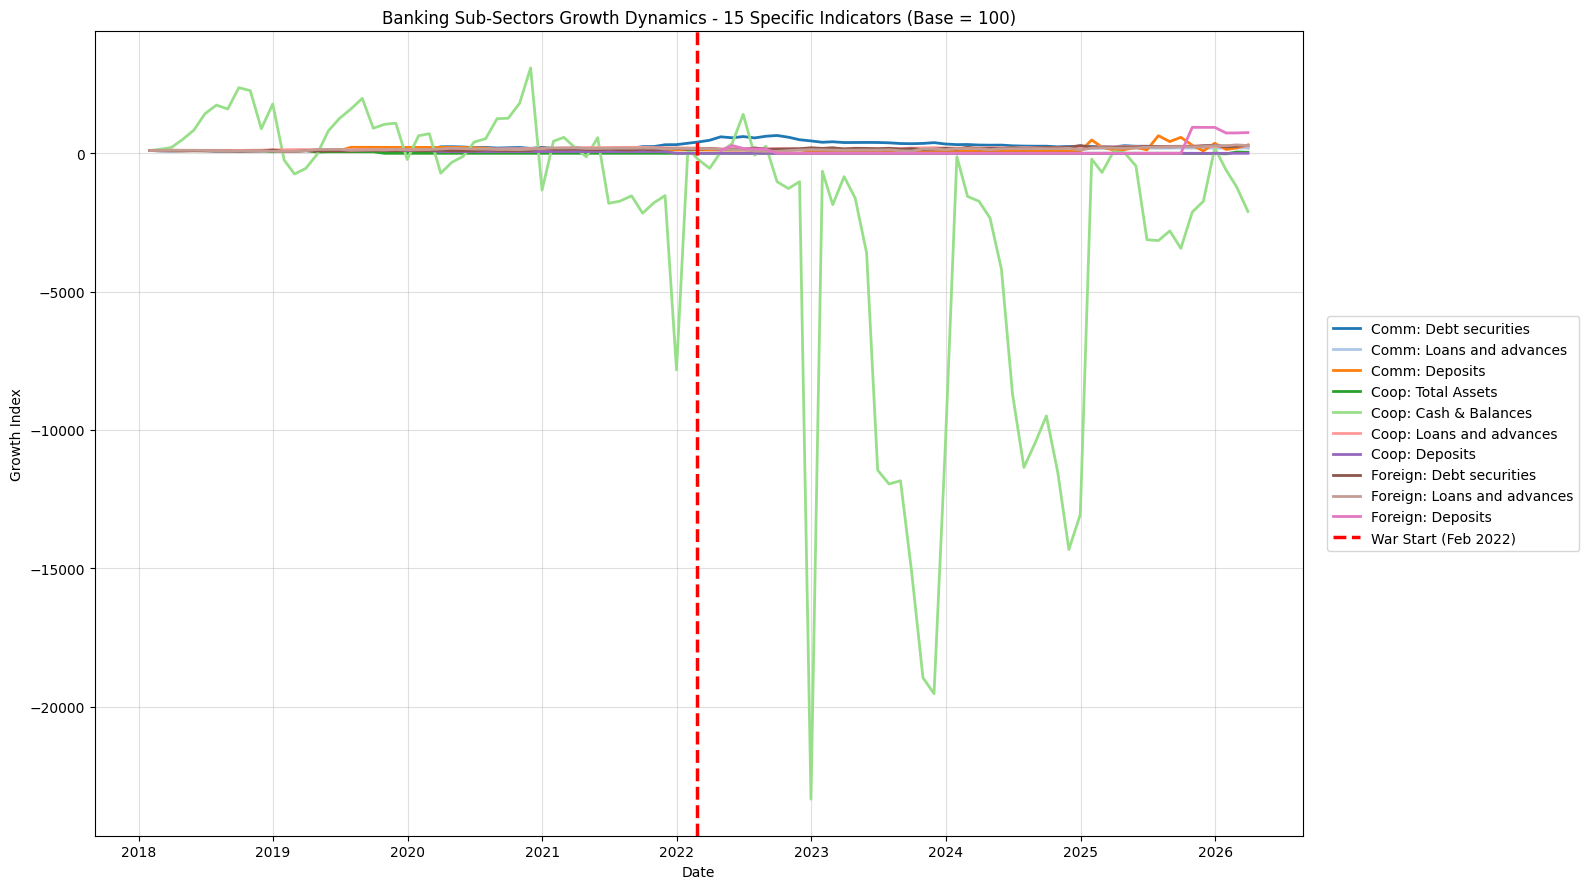

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "bank_data/Banking_sector_data_03_2026_98135.xlsx"
df = pd.read_excel(file_path, sheet_name='Balance sheet', header=None)

# 1. Знаходимо рядок з датами
date_row_index = -1
for i in range(15):
    row_data = df.iloc[i].dropna().astype(str).tolist()
    if any('2018' in val for val in row_data) and any('2020' in val for val in row_data):
        date_row_index = i
        break

dates_str = [str(val).split(' ')[0] for val in df.iloc[date_row_index].tolist() if str(val).startswith('20')]
dates = pd.to_datetime(dates_str)

# 2. Рівно 15 показників з сирих даних (без загального сектору)
indicators = {
    # Комерційні банки
    69:  "Comm: Total Assets",
    70:  "Comm: Cash & Balances",
    74:  "Comm: Debt securities",
    86:  "Comm: Loans and advances",
    107: "Comm: Deposits",
    
    # Кооперативні банки
    205: "Coop: Total Assets",
    206: "Coop: Cash & Balances",
    210: "Coop: Debt securities",
    222: "Coop: Loans and advances",
    243: "Coop: Deposits",
    
    # Філії іноземних банків
    137: "Foreign: Total Assets",
    138: "Foreign: Cash & Balances",
    142: "Foreign: Debt securities",
    154: "Foreign: Loans and advances",
    175: "Foreign: Deposits"
}

# 3. Будуємо графік
plt.figure(figsize=(16, 9))
colormap = plt.cm.get_cmap('tab20', 15)

color_idx = 0
for idx, label in indicators.items():
    row_index = date_row_index + idx
    raw_values = df.iloc[row_index].tolist()
    
    numeric_values = []
    for val in raw_values:
        val_str = str(val).strip()
        if val_str == 'nan' or val_str == '' or val_str.isalpha():
            continue
        try:
            num = float(val_str.replace(',', '.'))
            numeric_values.append(num)
        except ValueError:
            continue
            
    if len(numeric_values) >= len(dates):
        values_to_plot = numeric_values[-len(dates):]
        
        base_value = None
        base_idx = 0
        for i, v in enumerate(values_to_plot):
            if v != 0:
                base_value = v
                base_idx = i
                break
                
        if base_value is not None:
            normalized_values = [None] * base_idx + [(v / base_value) * 100 for v in values_to_plot[base_idx:]]
            plt.plot(dates, normalized_values, label=label, linewidth=2, color=colormap(color_idx))
            color_idx += 1

plt.axvline(pd.to_datetime('2022-02-24'), color='red', linestyle='--', linewidth=2.5, label='War Start (Feb 2022)')

plt.title("Banking Sub-Sectors Growth Dynamics - 15 Specific Indicators (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Growth Index")
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0., fontsize='medium')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

Raw DataFrame columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]

FOUND 67 INDICATORS:
LIST OF AVAILABLE FEATURES (COLUMNS):
--------------------------------------------------
- Total assets
- Cash, cash balances at central banks and other demand deposits
- Financial assets held for trading
- Derivatives
- Equity instruments
- Debt securities
- Loans and advances/ Other receivables
- Financial assets designated at fair value through profit or loss
- Equity instruments
- Debt securities
- Loans and advances/ Other receivables
- Financial assets at fair value through other comprehensive income/ Financial assets available for sale
- Equity instru

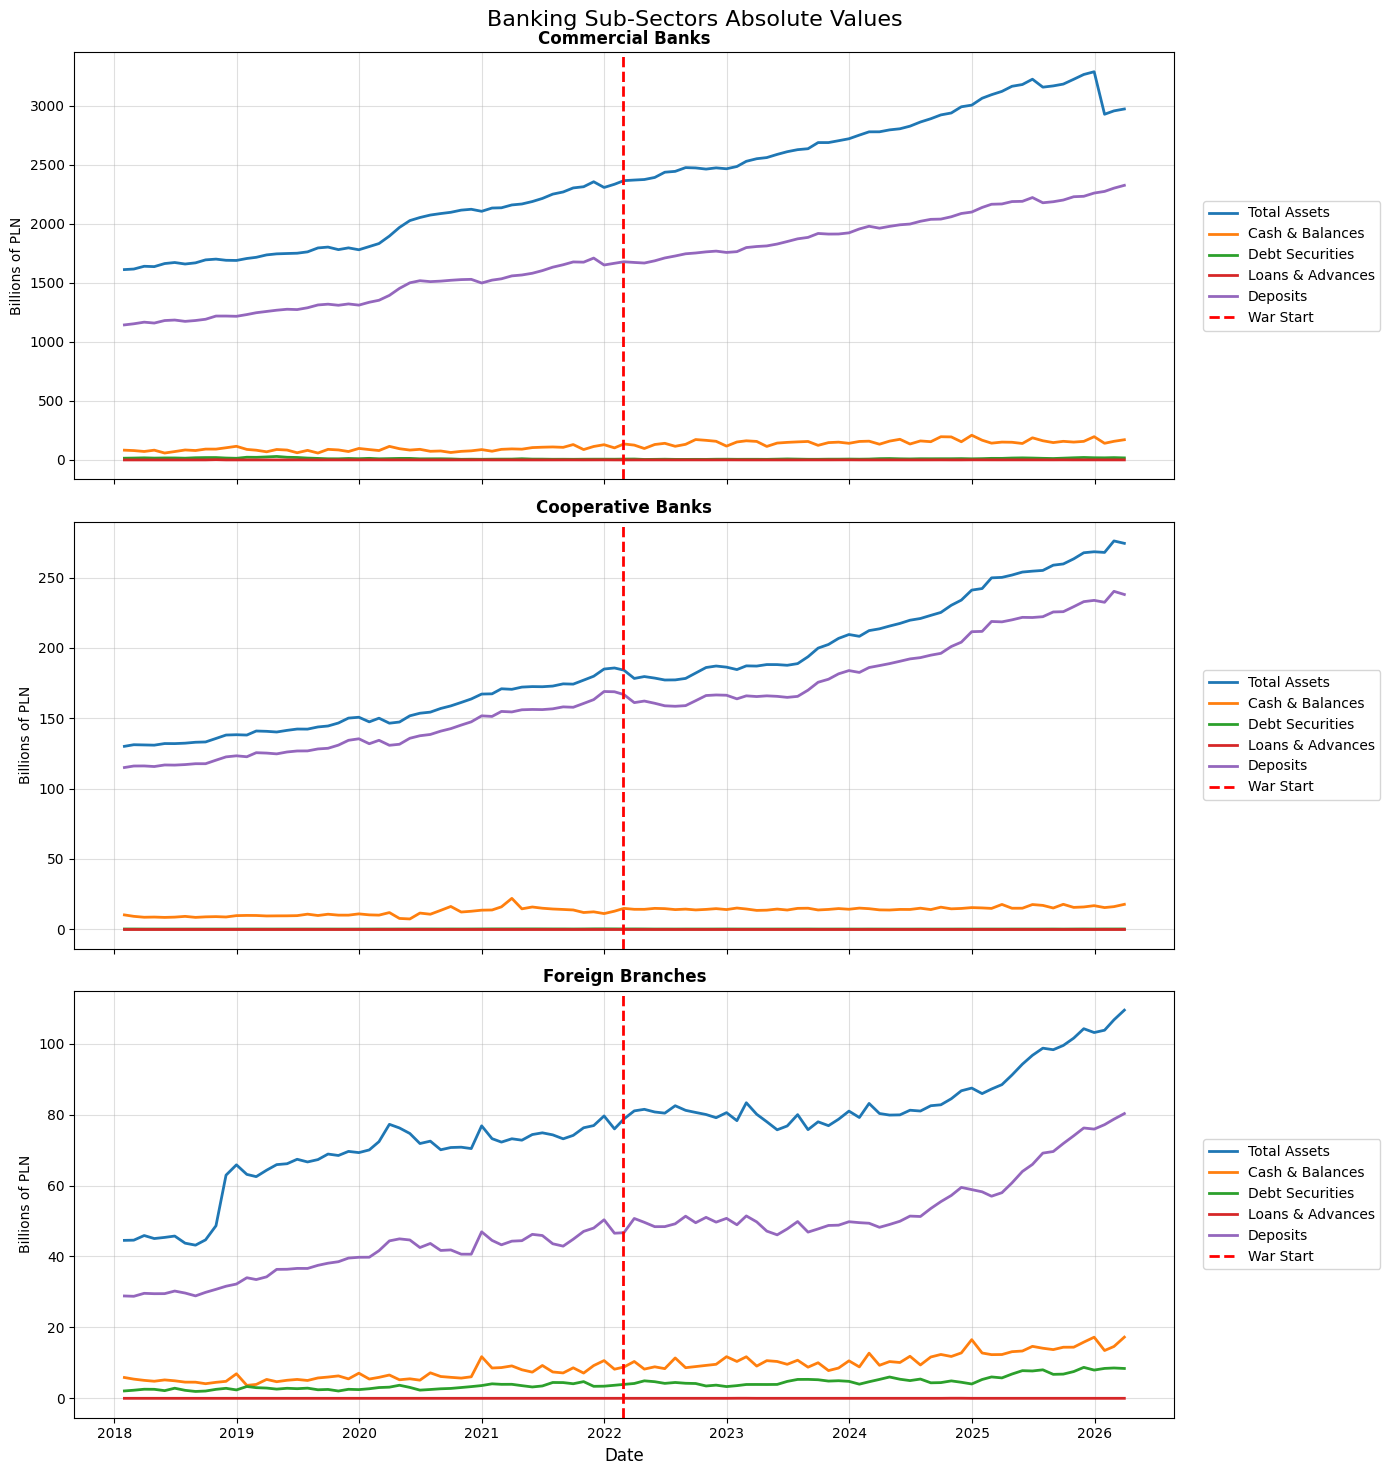

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "bank_data/Banking_sector_data_03_2026_98135.xlsx"
df = pd.read_excel(file_path, sheet_name='Balance sheet', header=None)

print("Raw DataFrame columns:", df.columns.tolist())

start_comm = df[df[0].astype(str).str.strip() == "Commercial banks operating with foreign branches"].index[0]
start_foreign = df[df[0].astype(str).str.strip() == "Branches of credit institutions and foreign banks"].index[0]
start_coop = df[df[0].astype(str).str.strip() == "Cooperative banks - operating"].index[0]

indicators_list = df.iloc[start_comm+1 : start_foreign, 0].dropna().astype(str).tolist()
valid_indicators = [i.strip() for i in indicators_list if i.strip()]

print(f"\nFOUND {len(valid_indicators)} INDICATORS:")
print("LIST OF AVAILABLE FEATURES (COLUMNS):")
print("-" * 50)
for ind in valid_indicators:
    print(f"- {ind}")
print("-" * 50)

date_row_index = -1
for i in range(15):
    row_data = df.iloc[i].dropna().astype(str).tolist()
    if any('2018' in val for val in row_data) and any('2020' in val for val in row_data):
        date_row_index = i
        break

dates_str = [str(val).split(' ')[0] for val in df.iloc[date_row_index].tolist() if str(val).startswith('20')]
dates = pd.to_datetime(dates_str)

print(f"\nExtracted {len(dates_str)} date columns:")
print(dates_str)

def get_values_in_slice(dataframe, start_idx, end_idx, indicator_name, occurrence=1):
    count = 0
    for idx in range(start_idx, end_idx):
        cell_value = str(dataframe.iloc[idx, 0]).strip()
        if cell_value == indicator_name:
            count += 1
            if count == occurrence:
                raw_vals = dataframe.iloc[idx].tolist()
                nums = []
                for val in raw_vals:
                    val_str = str(val).strip()
                    if val_str not in ('nan', '') and not val_str.isalpha():
                        try:
                            nums.append(float(val_str.replace(',', '.')) / 1000000000)
                        except ValueError:
                            pass
                return nums[-len(dates):] if len(nums) >= len(dates) else []
    return []

data_to_plot = {
    "Commercial Banks": {
        "Total Assets": get_values_in_slice(df, start_comm, start_foreign, "Total assets"),
        "Cash & Balances": get_values_in_slice(df, start_comm, start_foreign, "Cash, cash balances at central banks and other demand deposits"),
        "Debt Securities": get_values_in_slice(df, start_comm, start_foreign, "Debt securities", occurrence=1),
        "Loans & Advances": get_values_in_slice(df, start_comm, start_foreign, "Loans and advances/ Other receivables", occurrence=1),
        "Deposits": get_values_in_slice(df, start_comm, start_foreign, "Deposits", occurrence=3)
    },
    "Cooperative Banks": {
        "Total Assets": get_values_in_slice(df, start_coop, len(df), "Total assets"),
        "Cash & Balances": get_values_in_slice(df, start_coop, len(df), "Cash, cash balances at central banks and other demand deposits"),
        "Debt Securities": get_values_in_slice(df, start_coop, len(df), "Debt securities", occurrence=1),
        "Loans & Advances": get_values_in_slice(df, start_coop, len(df), "Loans and advances/ Other receivables", occurrence=1),
        "Deposits": get_values_in_slice(df, start_coop, len(df), "Deposits", occurrence=3)
    },
    "Foreign Branches": {
        "Total Assets": get_values_in_slice(df, start_foreign, start_coop, "Total assets"),
        "Cash & Balances": get_values_in_slice(df, start_foreign, start_coop, "Cash, cash balances at central banks and other demand deposits"),
        "Debt Securities": get_values_in_slice(df, start_foreign, start_coop, "Debt securities", occurrence=1),
        "Loans & Advances": get_values_in_slice(df, start_foreign, start_coop, "Loans and advances/ Other receivables", occurrence=1),
        "Deposits": get_values_in_slice(df, start_foreign, start_coop, "Deposits", occurrence=3)
    }
}

fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)
fig.suptitle("Banking Sub-Sectors Absolute Values", fontsize=16, y=0.98)

sectors = list(data_to_plot.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, sector in enumerate(sectors):
    ax = axes[i]
    indicators_dict = data_to_plot[sector]
    
    color_idx = 0
    for label, values in indicators_dict.items():
        if values:
            ax.plot(dates, values, label=label, linewidth=2, color=colors[color_idx])
        color_idx += 1
        
    ax.axvline(pd.to_datetime('2022-02-24'), color='red', linestyle='--', linewidth=2, label='War Start')
    ax.set_title(sector, fontsize=12, fontweight='bold')
    
    ax.set_ylabel("Billions of PLN")
    
    ax.grid(True, alpha=0.4)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    
    ax.ticklabel_format(style='plain', axis='y')

plt.xlabel("Date", fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

file_path = "bank_data/Banking_sector_data_03_2026_98135.xlsx"
output_file = "unique_features_KNF.txt"

# Завантажуємо весь Excel-файл (усі вкладки)
try:
    xls = pd.ExcelFile(file_path)
except FileNotFoundError:
    print(f"Помилка: Файл не знайдено за шляхом {file_path}")
    exit()

unique_features = set()

# Список слів-виключень, які є технічними заголовками, а не фінансовими фічами
stop_words = {
    'pln', 'data in', 'quantity', 'based on data reported on', 
    'back to the list of tables', 'banking sector with foreign branches',
    'cooperative banks - operating', 'branches of credit institutions and foreign banks'
}

# Проходимося по кожній вкладці
for sheet_name in xls.sheet_names:
    # Пропускаємо технічну вкладку Info
    if sheet_name == 'Info':
        continue
        
    df = pd.read_excel(xls, sheet_name=sheet_name, header=None)
    
    # Беремо всі значення з першої колонки (індекс 0)
    col_values = df.iloc[:, 0].dropna().astype(str).tolist()
    
    for val in col_values:
        clean_val = val.strip()
        
        # Фільтруємо:
        # 1. Порожні рядки
        # 2. Рядки, що починаються з '20' (це дати, напр. 2018-01-31)
        # 3. Службові слова (переводимо в нижній регістр для перевірки)
        # 4. Довгі примітки (зазвичай починаються з '*' або дуже довгі)
        if (clean_val and 
            not clean_val.startswith('20') and 
            not clean_val.startswith('*') and
            clean_val.lower() not in stop_words and
            len(clean_val) < 150): # Відкидаємо абзаци тексту
            
            unique_features.add(clean_val)

# Сортуємо за алфавітом для зручності читання
sorted_features = sorted(list(unique_features))

# Зберігаємо у текстовий файл
with open(output_file, 'w', encoding='utf-8') as f:
    f.write(f"РЕЄСТР УНІКАЛЬНИХ ФІНАНСОВИХ ПОКАЗНИКІВ KNF (Всього: {len(sorted_features)})\n")
    f.write("="*70 + "\n\n")
    for feature in sorted_features:
        f.write(f"{feature}\n")

print(f"Готово! Знайдено {len(sorted_features)} унікальних показників.")
print(f"Список збережено у файл: {output_file}")

Готово! Знайдено 260 унікальних показників.
Список збережено у файл: unique_features_KNF.txt
